In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

merged = pd.read_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet")

# convert to numeric
for col in ['INCLINATION', 'ECCENTRICITY', 'BSTAR', 'MEAN_MOTION', 'PERIOD', 'APOGEE', 'PERIGEE', 'SEMIMAJOR_AXIS']:
    merged[col] = pd.to_numeric(merged[col], errors='coerce')

print(merged.shape)
merged[['INCLINATION', 'ECCENTRICITY', 'BSTAR', 'MEAN_MOTION', 'PERIOD']].describe()

(66666, 54)


,INCLINATION,ECCENTRICITY,BSTAR,MEAN_MOTION,PERIOD
count,66666.000000,66666.000000,66666.000000,66666.000000,66666.000000
mean,68.835908,0.039742,0.180008,14.100146,198.332455
std,25.088499,0.139193,31.539650,3.837233,2194.468430
min,0.000000,0.000000,-5.373900,0.002962,81.643000
25%,52.919300,0.000555,0.000069,14.231426,89.235000
50%,70.003000,0.001867,0.000487,15.301916,94.106000
75%,96.638300,0.007038,0.002421,16.137173,101.185000
max,150.943700,0.996795,7460.000000,17.637674,486090.717000


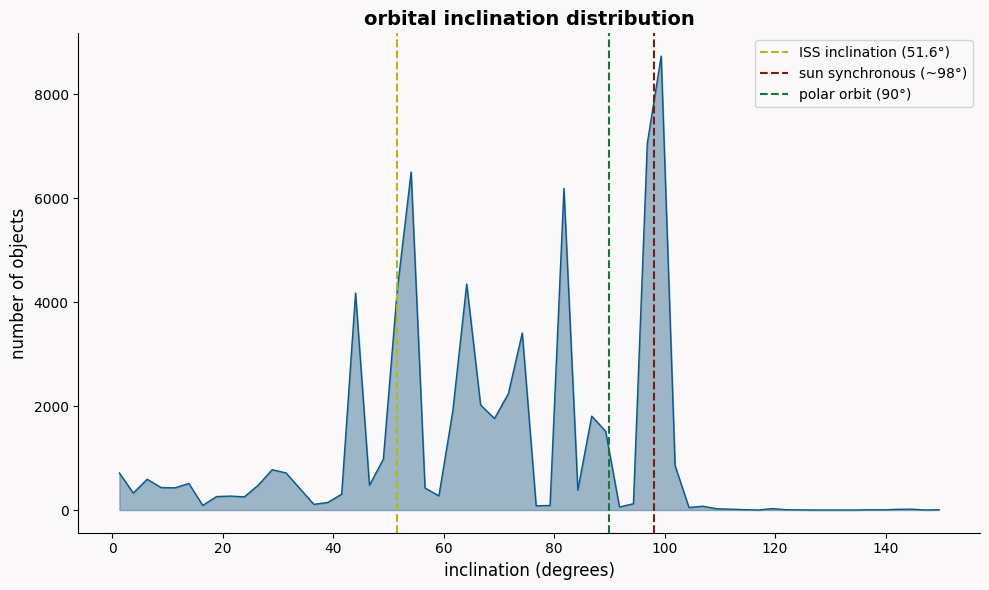

In [72]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#faf8f8")
ax.set_facecolor("#faf8f8")

clean = merged[merged['INCLINATION'].between(0, 180)]
counts, bins = np.histogram(clean['INCLINATION'], bins=60)
bin_centers = (bins[:-1] + bins[1:]) / 2

ax.plot(bin_centers, counts, color="#09598f", linewidth=1)
ax.fill_between(bin_centers, counts, alpha=0.4, color="#105482")

# mark important inclinations
ax.axvline(x=51.6, color="#b5b814", linestyle='--', linewidth=1.5, label='ISS inclination (51.6°)')
ax.axvline(x=98, color="#7a1c12", linestyle='--', linewidth=1.5, label='sun synchronous (~98°)')
ax.axvline(x=90, color="#12793d", linestyle='--', linewidth=1.5, label='polar orbit (90°)')

ax.set_title('orbital inclination distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('inclination (degrees)', fontsize=12)
ax.set_ylabel('number of objects', fontsize=12)
ax.tick_params(colors='black')
ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')
ax.title.set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(facecolor="#faf8f8", labelcolor='black')
plt.tight_layout()
plt.show()

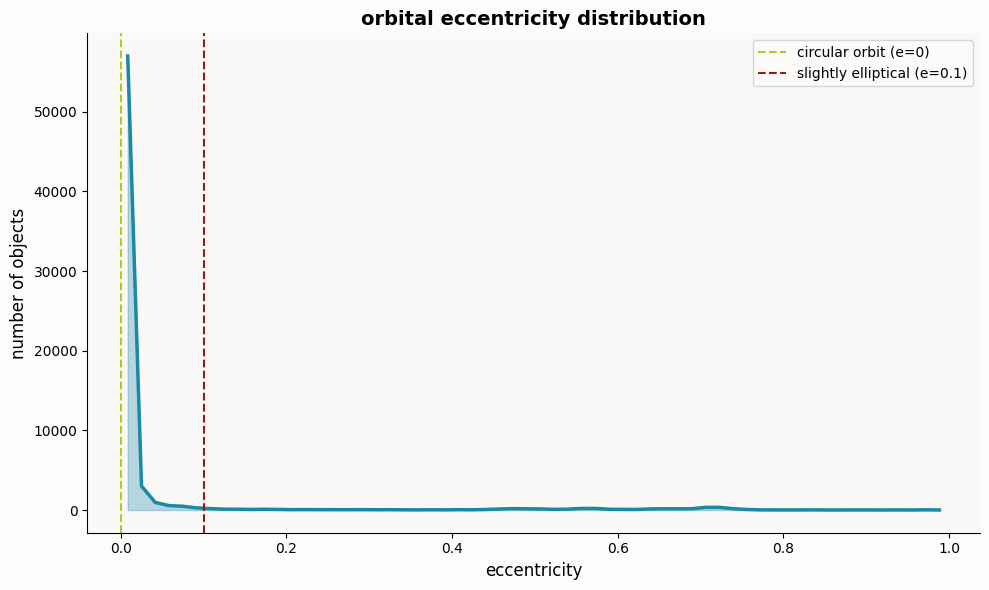

In [55]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#fefbfb")
ax.set_facecolor("#fbf8f8")

clean = merged[merged['ECCENTRICITY'].between(0, 1)]
counts, bins = np.histogram(clean['ECCENTRICITY'], bins=60)
bin_centers = (bins[:-1] + bins[1:]) / 2

ax.plot(bin_centers, counts, color="#1989A4", linewidth=2.5)
ax.fill_between(bin_centers, counts, alpha=0.3, color="#1987a3")

ax.axvline(x=0, color="#b0ca20", linestyle='--', linewidth=1.5, label='circular orbit (e=0)')
ax.axvline(x=0.1, color="#921e11", linestyle='--', linewidth=1.5, label='slightly elliptical (e=0.1)')

ax.set_title('orbital eccentricity distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('eccentricity', fontsize=12)
ax.set_ylabel('number of objects', fontsize=12)
ax.tick_params(colors='black')
ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')
ax.title.set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(facecolor="#fefbfb", labelcolor='black')
plt.tight_layout()
plt.show()

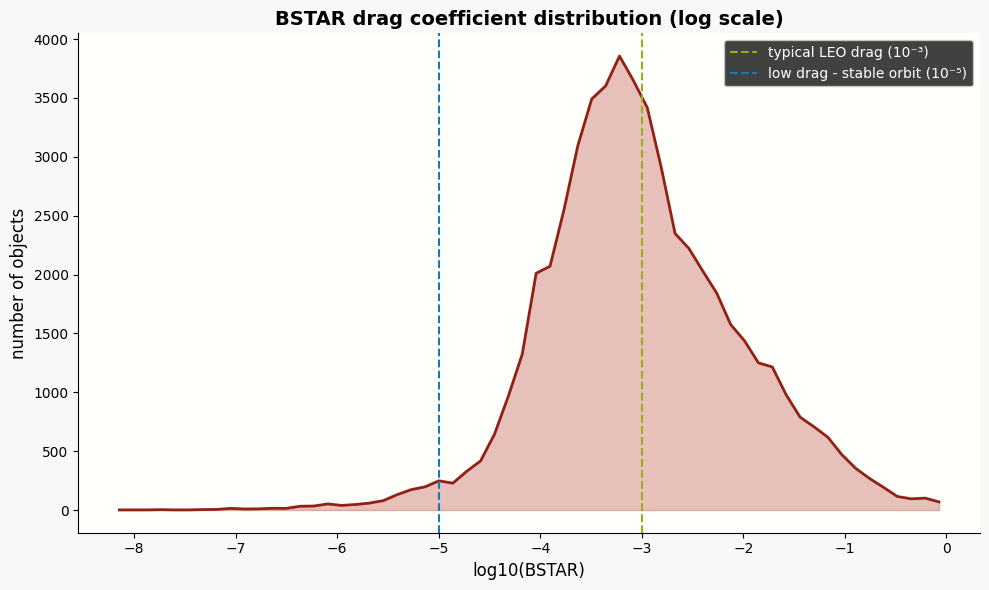

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#f9f8f8")
ax.set_facecolor("#fffffcff")

# log scale because bstar spans many orders of magnitude
clean = merged[(merged['BSTAR'] > 0) & (merged['BSTAR'] < 1)]
log_bstar = np.log10(clean['BSTAR'])

counts, bins = np.histogram(log_bstar.dropna(), bins=60)
bin_centers = (bins[:-1] + bins[1:]) / 2

ax.plot(bin_centers, counts, color="#912114", linewidth=2)
ax.fill_between(bin_centers, counts, alpha=0.3, color="#b22f203a")

ax.set_title('BSTAR drag coefficient distribution (log scale)', fontsize=14, fontweight='bold')
ax.set_xlabel('log10(BSTAR)', fontsize=12)
ax.set_ylabel('number of objects', fontsize=12)
ax.tick_params(colors='black')
ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')
ax.title.set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axvline(x=-3, color="#98af17", linestyle='--', linewidth=1.5, label='typical LEO drag (10⁻³)')
ax.axvline(x=-5, color="#1979b8", linestyle='--', linewidth=1.5, label='low drag - stable orbit (10⁻⁵)')
ax.legend(facecolor="#121111", labelcolor='white')
plt.tight_layout()
plt.show()

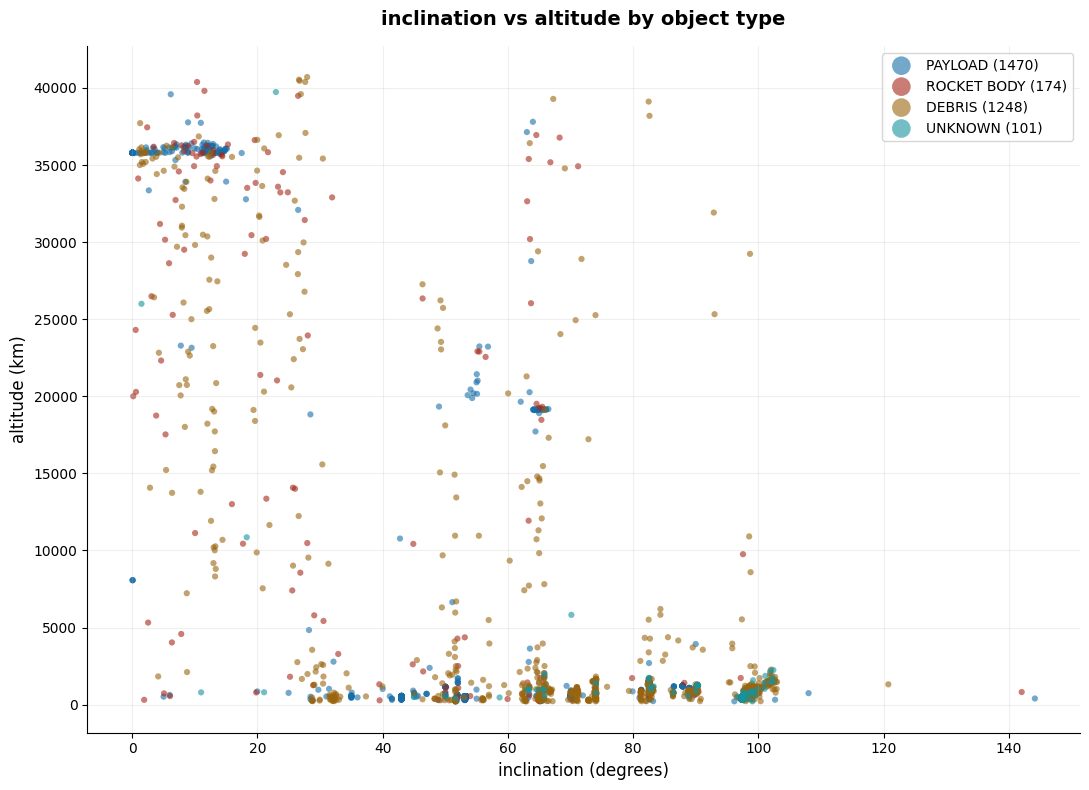

In [36]:
fig, ax = plt.subplots(figsize=(11, 8))

sample = merged[merged['altitude_km'].between(200, 42000)].sample(3000, random_state=42)

type_colors = {
    'PAYLOAD': "#176EA7",
    'ROCKET BODY': "#a52618",
    'DEBRIS': "#9a650f",
    'UNKNOWN': "#14949d"
}

for obj_type, color in type_colors.items():
    mask = sample['OBJECT_TYPE'] == obj_type
    if mask.sum() > 0:
        ax.scatter(sample[mask]['INCLINATION'], sample[mask]['altitude_km'],
                   c=color, s=20, alpha=0.6, label=f'{obj_type} ({mask.sum()})',
                   edgecolors='none')

ax.set_title('inclination vs altitude by object type', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('inclination (degrees)', fontsize=12)
ax.set_ylabel('altitude (km)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(markerscale=3)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

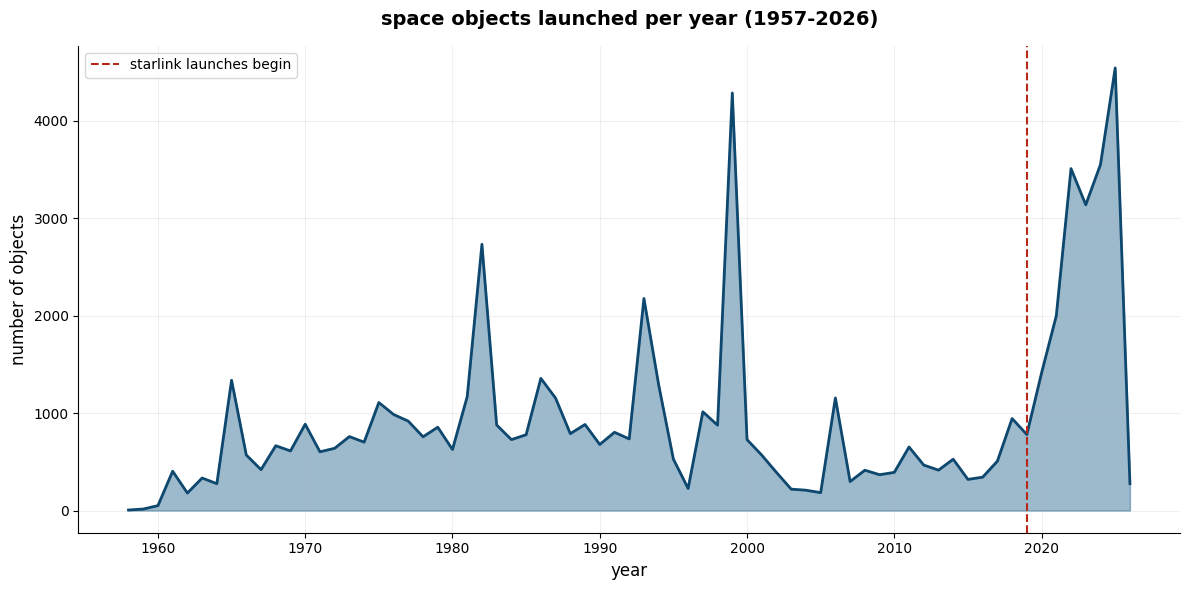

In [25]:
# launch year vs number of objects added per year
merged['LAUNCH_YEAR'] = pd.to_numeric(merged['LAUNCH_YEAR'], errors='coerce')
by_year = merged[merged['LAUNCH_YEAR'].between(1957, 2026)].groupby('LAUNCH_YEAR').size()

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(by_year.index, by_year.values, alpha=0.4, color="#0c5281")
ax.plot(by_year.index, by_year.values, color="#0e486f", linewidth=2)

ax.axvline(x=2019, color="#b82818", linestyle='--', linewidth=1.5, label='starlink launches begin')

ax.set_title('space objects launched per year (1957-2026)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('year', fontsize=12)
ax.set_ylabel('number of objects', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

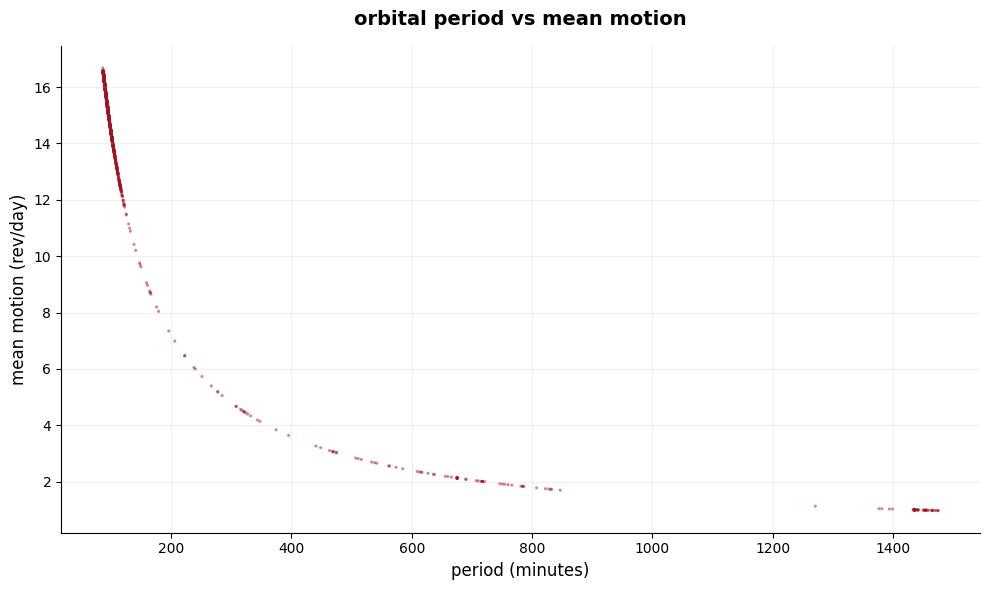

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

sample2 = merged[merged['PERIOD'].between(80, 1500)].sample(2000, random_state=42)
sample2['MEAN_MOTION'] = pd.to_numeric(sample2['MEAN_MOTION'], errors='coerce')

ax.scatter(sample2['PERIOD'], sample2['MEAN_MOTION'],
           c="#a61122", s=5, alpha=0.5, edgecolors='none')

ax.set_title('orbital period vs mean motion', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('period (minutes)', fontsize=12)
ax.set_ylabel('mean motion (rev/day)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()